以下代码是在kimi中输入“使用sklearn的iris数据集，给出聚类的代码示例”得到，并能完全跑通。

D:\DevSoft\python-venv\research-venv\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


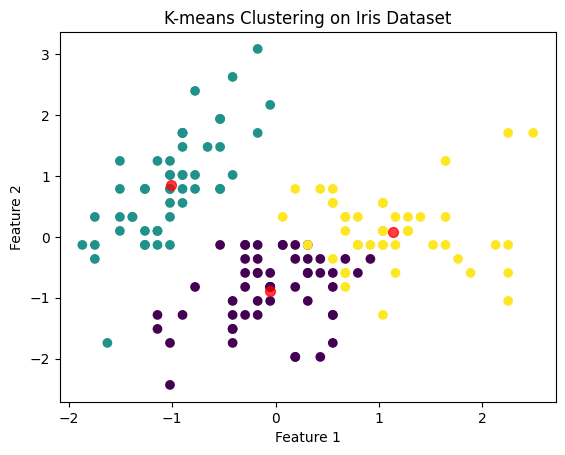

In [2]:
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 加载Iris数据集
iris = datasets.load_iris()
X = iris.data

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 创建KMeans实例，设置聚类数为3
kmeans = KMeans(n_clusters=3, random_state=42)

# 进行聚类
kmeans.fit(X_scaled)

# 获取聚类标签
labels = kmeans.labels_

# 可视化聚类结果
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', marker='o')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=50, alpha=0.75)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-means Clustering on Iris Dataset')
plt.show()

原始分类展示（实际数据是4维数据，当前只用了前面的2维表示展示 -- 可以认为4维空间投影到前2维）

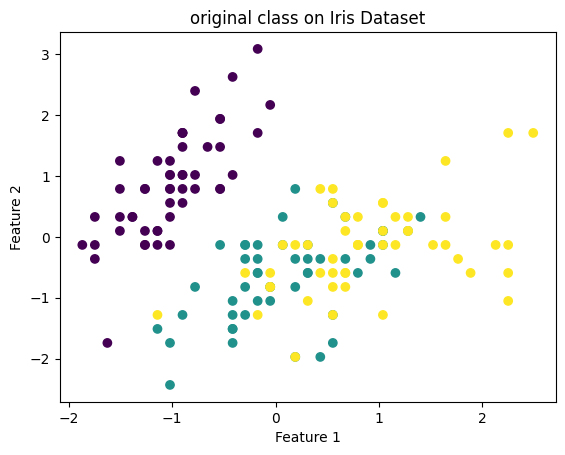

In [17]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=iris.target, cmap='viridis', marker='o')
plt.title('original class on Iris Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

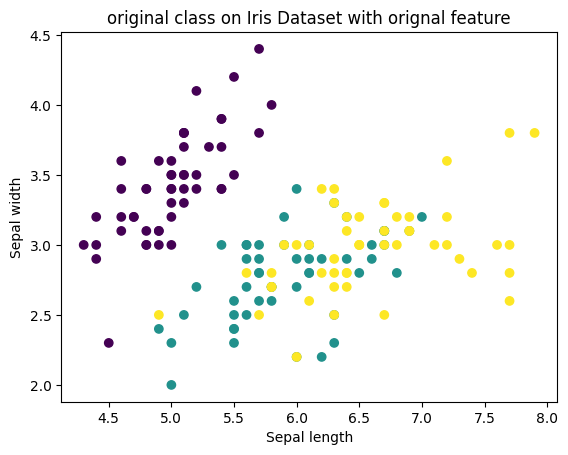

In [19]:
# 可视化结果
plt.scatter(X[:, 0], X[:, 1], c=iris.target, cmap='viridis')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('original class on Iris Dataset with orignal feature')
plt.show()

比较上面的两张图。1、点位置相同，则表明是同一样本；2、每张图中，同一种颜色代表代表同一种类。(注：当前不同图中同一种颜色并不表明同一种类)  
<span style="color: red;">显然聚类的结果与原始的花的类别不完全对应</span>，因为聚类是一种无监督学习方法，它不知道数据的真实标签。此外，选择合适的聚类数（在这个例子中是3）通常需要一些先验知识或使用如轮廓系数等方法来确定。

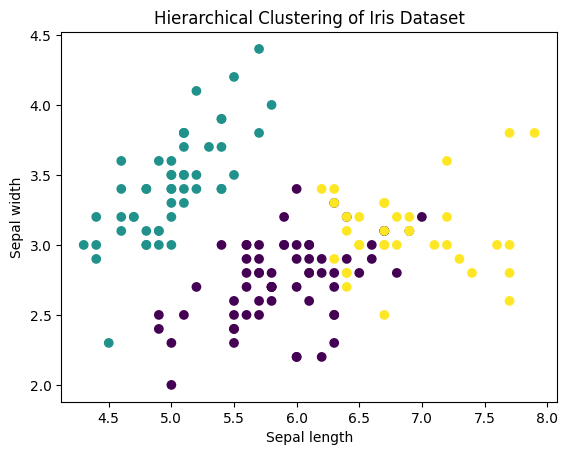

In [15]:
from sklearn import datasets
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# 加载iris数据集
iris = datasets.load_iris()
X = iris.data

# 创建层次聚类模型，设置聚类数量为3
model = AgglomerativeClustering(n_clusters=3)

# 拟合模型并进行预测
labels = model.fit_predict(X)

# 可视化结果
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Hierarchical Clustering of Iris Dataset')
plt.show()

以下代码是在kimi中输入“使用sklearn的iris数据集，给出层次聚类的代码示例”得到。 <span style="color: red;">运行的时候有个小错误（这个小错误，原因是低版本sklearn到高版本后api函数变更</span>，而kimi学习到的代码应该是历史低版本代码），根据提示修改后能跑通宵。

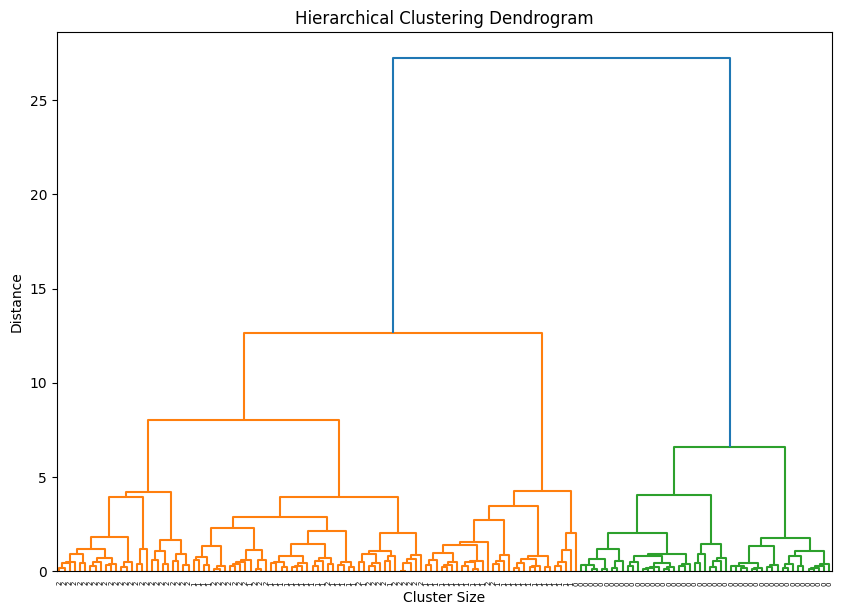

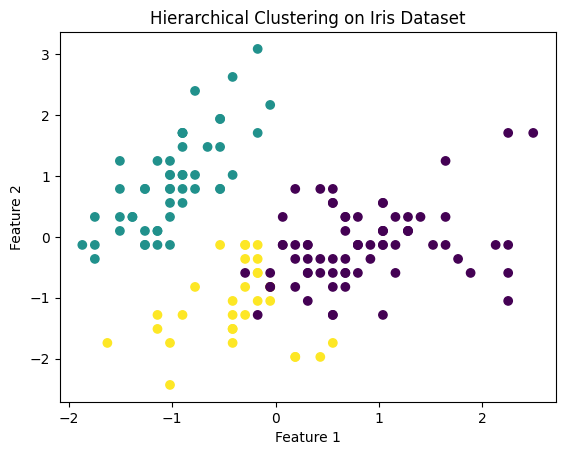

In [21]:
from sklearn import datasets
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# 加载Iris数据集
iris = datasets.load_iris()
X = iris.data

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 创建层次聚类实例
clustering = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
#clustering = AgglomerativeClustering(n_clusters=None, affinity='euclidean', linkage='ward')  #  Kimi生成的原始代码

# 进行层次聚类
clustering.fit(X_scaled)

# 获取聚类标签
labels = clustering.labels_

# 绘制树状图
# 这里使用scipy的dendrogram函数来绘制树状图
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked,
           orientation='top',
           labels=iris.target,
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.show()

# 可视化聚类结果
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', marker='o')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Hierarchical Clustering on Iris Dataset')
plt.show()